# 05 · Análisis de errores, limitaciones, test y archivo de entrega

1. ¿Dónde y por qué se equivoca el modelo? (ejemplos, papel de la lluvia reciente, dispersión, peores cuencas)
2. Limitaciones del enfoque
3. Predicciones del test → `outputs/submission.csv`
4. Reporte final en test (el test **no** se usó para tomar ninguna decisión)

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda v: f"{v:.5f}")
from resultados import *
from datos import DATASET
SEM = (42, 43, 44)
FINAL = [f"final_cd_s{s}" for s in SEM]        # Adapformer FINAL: k = 12 (CD), 3 semillas — elegido por val MSE
K4 = [f"p1_log_s{s}" for s in SEM]              # Adapformer con top-k adaptativo (k = 4, método completo del paper)
LSTM = [f"lstm_s{s}" for s in SEM]              # modelo base
E1 = pd.read_csv(ROOT / "referencias_estudio1" / "resultados_val.csv").set_index("run")

## 1. Ejemplos: lo que el modelo hace bien y lo que no puede hacer

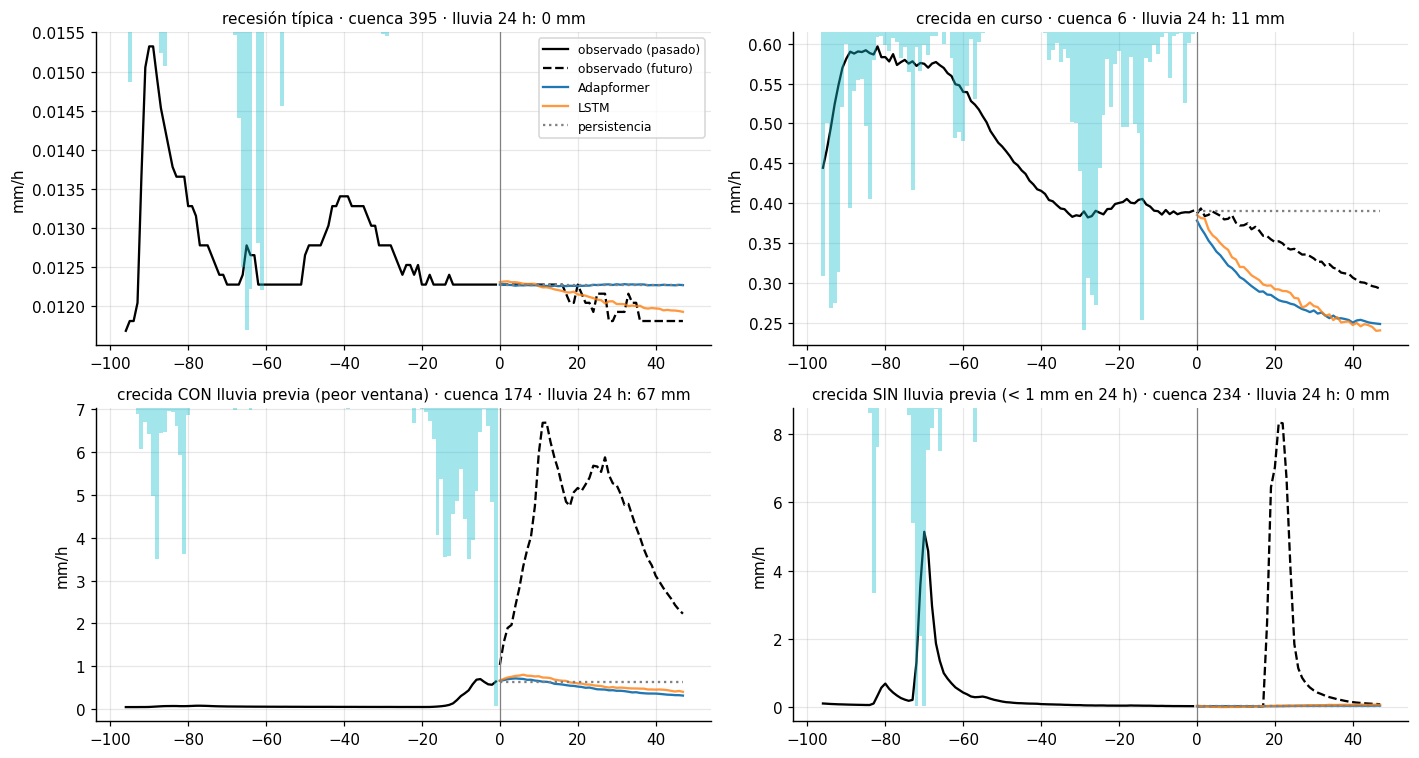

In [2]:
import h5py
from datos import CACHE, cargar_stats
y, b, lq = verdad("validation")
P_AF, P_LSTM, P_PERS = ensamble(FINAL), ensamble(LSTM), persistencia("validation")
err = ((P_AF - y) ** 2).mean(1)
ymax = y.max(1); thr = np.quantile(ymax, .9)
# lluvia acumulada en las últimas 24 h de la ventana (mm), recuperada de la caché transformada
mu, sd = cargar_stats()
def lluvia24(split):
    Xc = np.load(CACHE / f"X_{split}.npy", mmap_mode="r")
    return np.expm1(Xc[:, -24:, 8].astype(np.float32) * sd[8] + mu[8]).clip(0).sum(1)
p24 = lluvia24("validation")
inicio = (ymax > thr) & (y[:, 0] < 0.3 * ymax)          # la crecida arranca dentro del horizonte
rng = np.random.default_rng(0)
casos = {"recesión típica": rng.choice(np.flatnonzero((ymax < thr) & (y[:, -1] < y[:, 0]))),
         "crecida en curso": rng.choice(np.flatnonzero((ymax > thr) & (y[:, 0] > 0.8 * ymax))),
         "crecida CON lluvia previa (peor ventana)": int(np.argmax(err)),
         "crecida SIN lluvia previa (< 1 mm en 24 h)": int(np.argmax(np.where(inicio & (p24 < 1), err, -1)))}
rows = np.flatnonzero(h5py.File(DATASET / "train.h5", "r")["split"][:] == 1)
fig, axs = plt.subplots(2, 2, figsize=(13, 7)); axs = axs.ravel()
with h5py.File(DATASET / "train.h5", "r") as f:
    for ax, (titulo, i) in zip(axs, casos.items()):
        X = f["X"][rows[i]]
        ax.plot(range(-96, 0), X[-96:, 11], "k", label="observado (pasado)")
        ax.plot(range(48), y[i], "k--", label="observado (futuro)")
        ax.plot(range(48), P_AF[i], "C0", label="Adapformer"); ax.plot(range(48), P_LSTM[i], "C1", alpha=.8, label="LSTM")
        ax.plot(range(48), P_PERS[i], ":", color="gray", label="persistencia")
        ax2 = ax.twinx(); ax2.bar(range(-96, 0), X[-96:, 8], color="C9", alpha=.4, width=1); ax2.invert_yaxis(); ax2.set_yticks([])
        ax.axvline(0, color="gray", lw=.8); ax.set_title(f"{titulo} · cuenca {b[i]} · lluvia 24 h: {p24[i]:.0f} mm", fontsize=10); ax.set_ylabel("mm/h")
axs[0].legend(fontsize=8); plt.tight_layout(); plt.show()

* **Recesiones y flujo base:** se pronostican muy bien; el anclaje evita el salto inicial.
* **Crecida en curso:** el modelo sigue la recesión, aunque baja algo más rápido que lo observado.
* **Crecida con lluvia previa:** la lluvia ya cayó (barras azules en las últimas horas), pero el modelo apenas
  reacciona. Es el tipo de ventana con más error.
* **Crecida sin lluvia previa:** con esta entrada es imposible de anticipar.

¿Cuál de los dos últimos casos domina el error? Lo medimos.

## 2. ¿De dónde viene el error? La lluvia de las últimas 24 h

In [3]:
sse = ((P_AF - y) ** 2).sum(1)
filas = {}
for lab, m in [("crecida que inicia en el horizonte, < 1 mm en 24 h", inicio & (p24 < 1)),
               ("crecida que inicia en el horizonte, 1–10 mm", inicio & (p24 >= 1) & (p24 < 10)),
               ("crecida que inicia en el horizonte, > 10 mm", inicio & (p24 >= 10)),
               ("resto de crecidas (ya en curso)", (ymax > thr) & ~inicio),
               ("sin crecida", ymax <= thr)]:
    filas[lab] = {"ventanas": int(m.sum()), "% del error total": 100 * sse[m].sum() / sse.sum(),
                  "pico real medio": ymax[m].mean(), "pico predicho medio": P_AF[m].max(1).mean()}
display(pd.DataFrame(filas).T.round(3))

cal = {}
for lab, lo, hi in [("< 1 mm", 0, 1), ("1–10 mm", 1, 10), ("10–30 mm", 10, 30), ("> 30 mm", 30, 1e9)]:
    m = (p24 >= lo) & (p24 < hi)
    cal[lab] = {"ventanas": int(m.sum()), "% que termina en crecida": 100 * (ymax[m] > thr).mean(),
                "caudal medio real": y[m].mean(), "predicho Adapformer": P_AF[m].mean(), "predicho LSTM": P_LSTM[m].mean(),
                "predicho / real (Adapformer)": P_AF[m].mean() / y[m].mean()}
print("Calibración según la lluvia de las últimas 24 h:")
display(pd.DataFrame(cal).T.round(4))

,ventanas,% del error total,pico real medio,pico predicho medio
"crecida que inicia en el horizonte, < 1 mm en 24 h",186.00000,13.34400,0.69700,0.06600
"crecida que inicia en el horizonte, 1–10 mm",186.00000,25.84400,0.93500,0.11900
"crecida que inicia en el horizonte, > 10 mm",137.00000,32.44700,1.12400,0.19300
resto de crecidas (ya en curso),1306.00000,26.56000,0.60900,0.50100
sin crecida,16327.00000,1.80500,0.04100,0.03700


Calibración según la lluvia de las últimas 24 h:


,ventanas,% que termina en crecida,caudal medio real,predicho Adapformer,predicho LSTM,predicho / real (Adapformer)
< 1 mm,12435.00000,5.07440,0.04150,0.04020,0.04030,0.96880
1–10 mm,3919.00000,14.18730,0.08360,0.07340,0.07260,0.87710
10–30 mm,1429.00000,28.06160,0.15800,0.13130,0.13340,0.83080
> 30 mm,359.00000,63.23120,0.41450,0.37020,0.38950,0.89310


**Lectura (corrige una idea intuitiva pero equivocada).** Habría sido fácil decir que el modelo falla en las crecidas
"porque la lluvia todavía no cayó". Los datos dicen otra cosa:

* Las crecidas que empiezan dentro del horizonte explican ~70 % del error, y **la mayor parte ocurre con lluvia ya
  caída**. Las crecidas sin lluvia previa, realmente imposibles de anticipar con esta entrada, son solo ~13 % del error.
* Pero incluso con 10–30 mm en 24 h, **solo ~30 % de las ventanas termina en crecida**. Que la lluvia se convierta en
  crecida depende de estados que el modelo no observa: humedad del suelo, intensidad y distribución espacial de la
  lluvia, nieve. Con error cuadrático, lo óptimo ante esa incertidumbre es predecir el valor esperado, que queda muy
  por debajo del pico cuando la crecida sí ocurre.
* Además hay un **sesgo sistemático de −11 a −17 %** en las ventanas lluviosas, igual en Adapformer y en el LSTM. Es
  el sesgo de retransformación de entrenar en espacio log: `expm1(media de log)` estima algo cercano a la mediana, no la
  media. La pérdida híbrida (log + mm/h) apuntaba justamente a este sesgo y no mejoró el MSE global (notebook 04);
  un factor de corrección posterior tipo *smearing*, estimado en train, queda como trabajo futuro.

## 3. Observado vs predicho

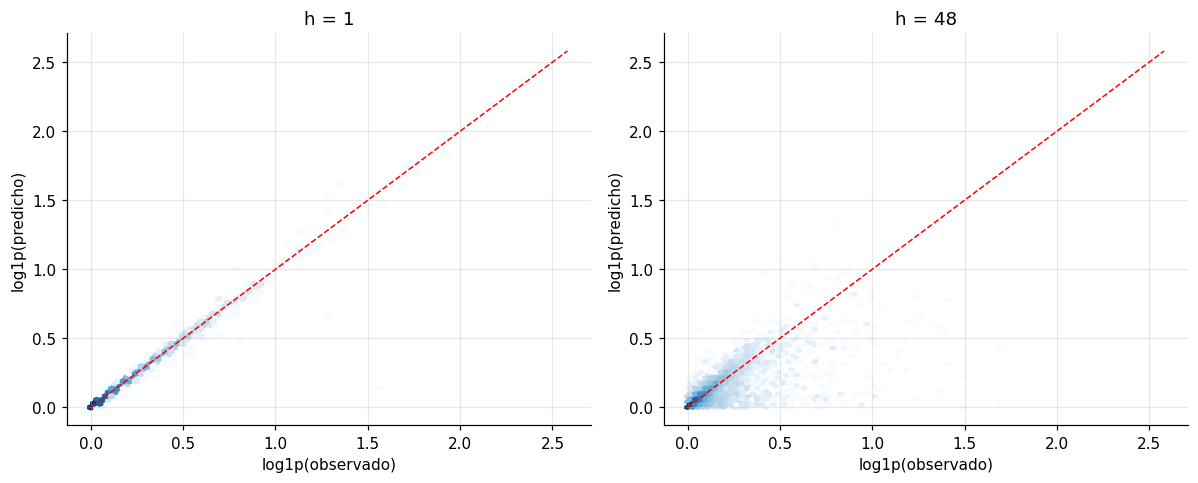

sesgo en crecidas: -0.0682 mm/h · error relativo mediano del pico: -17.6 %


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, h in zip(ax, (1, 48)):
    a.hexbin(np.log1p(y[:, h - 1]), np.log1p(P_AF[:, h - 1]), gridsize=60, bins="log", cmap="Blues", mincnt=1)
    m = np.log1p(y.max()); a.plot([0, m], [0, m], "r--", lw=1)
    a.set(title=f"h = {h}", xlabel="log1p(observado)", ylabel="log1p(predicho)")
plt.tight_layout(); plt.show()
m = metricas_de(P_AF)
print(f"sesgo en crecidas: {m['bias_flood']:.4f} mm/h · error relativo mediano del pico: {100 * m['peak_rel_err_flood']:.1f} %")

A 1 h los puntos siguen la diagonal. A 48 h hay mucha dispersión y los caudales altos quedan **debajo** de la
diagonal: subestimación sistemática de picos (regresión a la media, típica al minimizar error cuadrático en espacio log).

## 4. Peores cuencas: el problema de la NSE con varianza casi nula

In [5]:
nse = nse_por_cuenca(P_AF)
info = pd.DataFrame({"NSE": nse, "caudal medio": pd.Series(y.mean(1)).groupby(b).mean(),
                     "σ observada": pd.Series(y.ravel()).groupby(np.repeat(b, 48)).std(),
                     "ventanas": pd.Series(b).value_counts()})
display(info.sort_values("NSE").head(8))
print("correlación de Spearman entre NSE y σ observada:", round(info[["NSE", "σ observada"]].corr("spearman").iloc[0, 1], 3))

,NSE,caudal medio,σ observada,ventanas
377,-29.73733,0.00002,0.00012,40
369,-6.97752,0.00004,0.00002,26
442,-4.74026,0.01428,0.01420,31
284,-3.83060,0.00318,0.02173,40
433,-2.35164,0.01406,0.04261,31
368,-1.69072,0.00198,0.01222,40
393,-1.42779,0.02098,0.06746,28
398,-1.11393,0.00300,0.01067,34


correlación de Spearman entre NSE y σ observada: -0.022


Las peores NSE aparecen en cuencas con **caudal casi constante** en validación (σ diminuta): como la NSE divide por
la varianza observada, un error absoluto minúsculo da una NSE muy negativa. Por eso reportamos la mediana y el p25.

## 5. Limitaciones

| # | Limitación | Consecuencia | Qué haría falta |
|---|---|---|---|
| 1 | La respuesta de la cuenca a la lluvia es muy incierta (solo ~30 % de las lluvias fuertes termina en crecida) | Picos muy subestimados; ~70 % del MSE en crecidas que inician en el horizonte | Estados no observados: humedad del suelo, nieve; atributos de cuenca |
| 1b | Sin lluvia futura como entrada | ~13 % del error: crecidas sin lluvia previa, imposibles de anticipar | Pronóstico meteorológico como entrada |
| 1c | Sesgo de retransformación del espacio log | −11 a −17 % en ventanas lluviosas | Corrección tipo *smearing* o pérdida en mm/h mejor calibrada |
| 2 | Top-k no diferenciable | El SimBlock sólo aprende por la pérdida aux.; `W_dec` casi uniforme | Gumbel-top-k / sparsemax |
| 3 | Pocas variables (12) | La selección de canales tiene poco margen | Más variables o atributos de cuenca |
| 4 | Validación con las mismas cuencas, ventanas solapadas | Métricas optimistas, validación ruidosa | Validación por cuencas no vistas, más semillas |
| 5 | Embedding lineal de 336 h | Comprime la dinámica reciente; el LSTM la recorre hora a hora | Embeddings por parches o multiescala |
| 6 | Hiperparámetros elegidos con la misma validación reportada | Ligero sesgo optimista | Validación anidada |

## 6. Predicciones del test y archivo de entrega

El modelo final es el **ensamble de 3 semillas de Adapformer con k = 12**. Cada corrida ya guardó sus predicciones del test
(`outputs/<corrida>/pred_test.npy`, en mm/h, recortadas a ≥ 0); aquí las promediamos y escribimos el CSV con el mismo
formato que `test_targets.csv` (`Id, q_01 … q_48`).

In [6]:
P_TEST = np.clip(ensamble(FINAL, "test"), 0, None)
cols = [f"q_{h:02d}" for h in range(1, 49)]
sub = pd.DataFrame(P_TEST, columns=cols); sub.insert(0, "Id", np.arange(len(sub)))
assert sub.columns.tolist() == ["Id"] + cols, "columnas distintas al formato del enunciado"
if (DATASET / "test_targets.csv").exists():  # además, mismo formato que el archivo de referencia
    assert sub.columns.tolist() == pd.read_csv(DATASET / "test_targets.csv", nrows=1).columns.tolist()
assert len(sub) == 27983 and np.isfinite(P_TEST).all() and (P_TEST >= 0).all()
sub.to_csv(OUT / "submission.csv", index=False, float_format="%.6g")
print(f"submission.csv: {sub.shape} ✔ formato verificado")
sub.head()

submission.csv: (27983, 49) ✔ formato verificado


,Id,q_01,q_02,q_03,q_04,q_05,q_06,q_07,q_08,q_09,...,q_39,q_40,q_41,q_42,q_43,q_44,q_45,q_46,q_47,q_48
0,0,0.18016,0.18022,0.17963,0.17939,0.17840,0.17641,0.17570,0.17637,0.17107,...,0.16961,0.17131,0.16922,0.16769,0.16807,0.16605,0.16888,0.16826,0.17318,0.16860
1,1,0.01859,0.01841,0.01825,0.01816,0.01793,0.01784,0.01779,0.01767,0.01747,...,0.01622,0.01624,0.01597,0.01617,0.01612,0.01615,0.01615,0.01612,0.01597,0.01599
2,2,0.00265,0.00265,0.00265,0.00265,0.00264,0.00265,0.00266,0.00267,0.00267,...,0.00297,0.00298,0.00297,0.00298,0.00298,0.00298,0.00298,0.00299,0.00299,0.00300
3,3,0.01741,0.01699,0.01663,0.01623,0.01592,0.01545,0.01512,0.01465,0.01443,...,0.00974,0.00965,0.00963,0.00961,0.00960,0.00953,0.00952,0.00944,0.00945,0.00937
4,4,0.00094,0.00093,0.00093,0.00092,0.00092,0.00093,0.00103,0.00102,0.00105,...,0.00263,0.00262,0.00261,0.00262,0.00261,0.00257,0.00261,0.00262,0.00265,0.00273


## 7. Reporte final en test

`test_targets.csv` (opcional) trae los valores reales. Los usamos **sólo aquí, al final**, como reporte: ninguna época,
hiperparámetro ni variante se eligió mirando el test.

In [7]:
if not (CACHE / "y_test.npy").exists():   # test_targets.csv es opcional
    print("No se encontró test_targets.csv: se omite el reporte en test.")
else:
    E1t = pd.read_csv(ROOT / "referencias_estudio1" / "test_report.csv").set_index("modelo")
    rep = {}
    for nombre, p in [("Persistencia", persistencia("test")), ("Adapformer k=12 · ensamble 3 semillas (FINAL)", P_TEST),
                      ("Adapformer k=4 · ensamble 3 semillas", ensamble(K4, "test")),
                      ("LSTM · ensamble 3 semillas", ensamble(LSTM, "test")),
                      ("Adapformer ×3 + LSTM ×3", (P_TEST + ensamble(LSTM, "test")) / 2)]:
        m = metricas_de(p, "test")
        rep[nombre] = {"MSE": m["MSE"], "MAE": m["MAE"], "NSE mediana": m["NSE_median"], "KGE mediana": m["KGE_median"]}
    rep["Versión inicial · Adapformer k=4 (1 semilla)"] = {"MSE": E1t.loc["adapformer_full", "MSE"], "MAE": E1t.loc["adapformer_full", "MAE"],
                                           "NSE mediana": E1t.loc["adapformer_full", "NSE_median"], "KGE mediana": E1t.loc["adapformer_full", "KGE_median"]}
    R = pd.DataFrame(rep).T
    R["Δ MSE vs persistencia"] = (R.MSE / R.loc["Persistencia", "MSE"] - 1).map(lambda v: f"{100 * v:+.1f} %")
    display(R)

,MSE,MAE,NSE mediana,KGE mediana,Δ MSE vs persistencia
Persistencia,0.01411,0.02461,0.49162,0.62617,+0.0 %
Adapformer k=12 · ensamble 3 semillas (FINAL),0.01086,0.02047,0.60065,0.67512,-23.0 %
Adapformer k=4 · ensamble 3 semillas,0.01109,0.02033,0.60693,0.67618,-21.4 %
LSTM · ensamble 3 semillas,0.01091,0.02070,0.60117,0.67530,-22.7 %
Adapformer ×3 + LSTM ×3,0.01073,0.02025,0.60404,0.68634,-24.0 %
Versión inicial · Adapformer k=4 (1 semilla),0.01135,0.02103,0.59041,0.66652,-19.6 %
